<a href="https://colab.research.google.com/github/gitnicolas343/python_estudio/blob/main/uniones_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth   #conexion a mi cuenta para usar los datos
auth.authenticate_user()


<div style="text-align: justify; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6;">

# UNIONES EN SQL

Con fines de estudio y desarrollo de este notebook, se utilizaron conjuntos de datos abiertos organizados en un entorno de trabajo que facilitara su consulta, exploración y análisis. Como parte del proceso, los datos fueron almacenados y trabajados en **Google BigQuery**, donde se realizaron validaciones básicas de estructura, consultas SQL y operaciones de unión entre tablas.

Posteriormente, los resultados fueron integrados en **Google Colab**, aprovechando este entorno para documentar el proceso en markdown, complementar el análisis con Python y generar visualizaciones de apoyo. De esta manera, se construyó un flujo de trabajo orientado no solo al procesamiento de los datos, sino también a presentarlos de forma clara, ordenada y accesible para su interpretación. El esquema del proceso es el siguiente:
(cabe destacar que estos datos e la arquitectura medallion corresponden a la capa bronce)
</div>

<center>

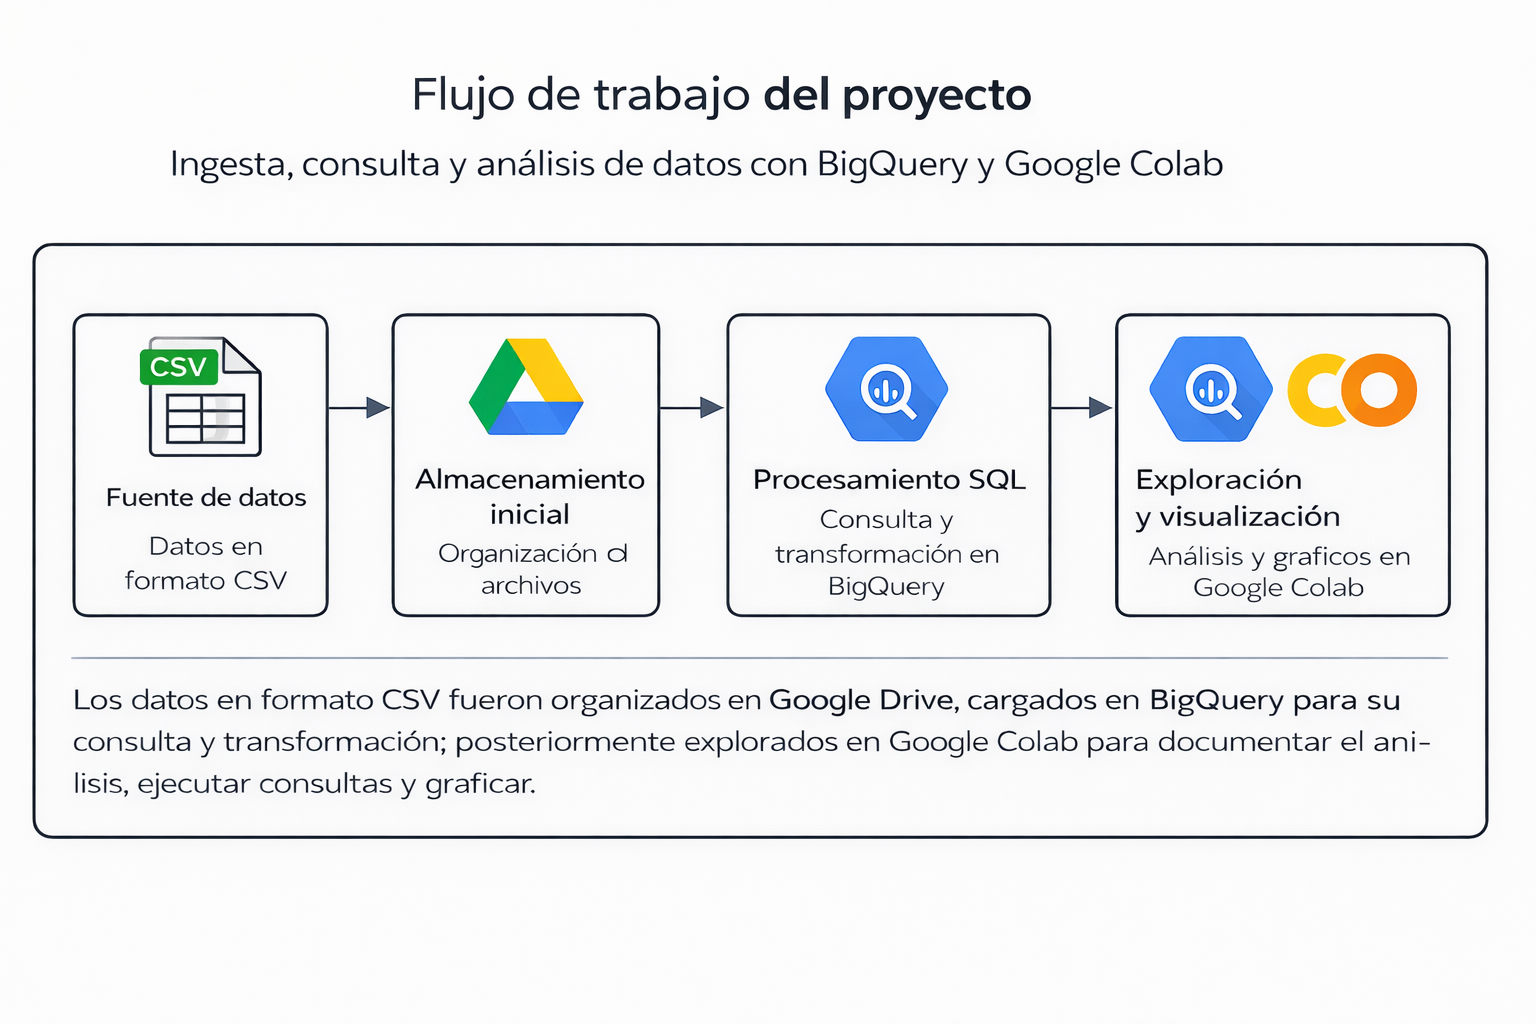

</center>



<div style="text-align: justify; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6;">

Este notebook ofrece una introducción práctica al uso de uniones en SQL, acompañada de explicaciones, consultas aplicadas y gráficos asociados, con el objetivo de mostrar un análisis reproducible que combina **BigQuery, SQL, Python y Google Colab** dentro de un mismo proyecto.

</div>

#ENTENDIMIENTO DE LA BASE DE DATOS:

##Base de datos de líderes mundiales

La base de datos de líderes mundiales es una base de datos relacional orientada al análisis político e institucional de distintos países. Su estructura está compuesta por varias tablas conectadas entre sí, entre las que se encuentran **presidentes**, **primeros_ministros**, **monarcas**, **estados** y **mandatos_primer_ministro**. Cada una almacena información específica sobre una dimensión del liderazgo o del contexto histórico de los países.

Las tablas de **presidentes**, **primeros_ministros** y **monarcas** permiten identificar qué tipo de figura de gobierno está presente en cada país, mientras que la tabla **estados** incorpora información histórica complementaria, como los años de independencia. Por su parte, **mandatos_primer_ministro** agrega datos relacionados con los periodos en los que los primeros ministros asumieron el cargo.

En conjunto, esta base de datos permite relacionar información de distintas estructuras de gobierno y compararla entre países, lo que la convierte en un buen entorno para explorar consultas relacionales, cruces de información y análisis con SQL.


<center>

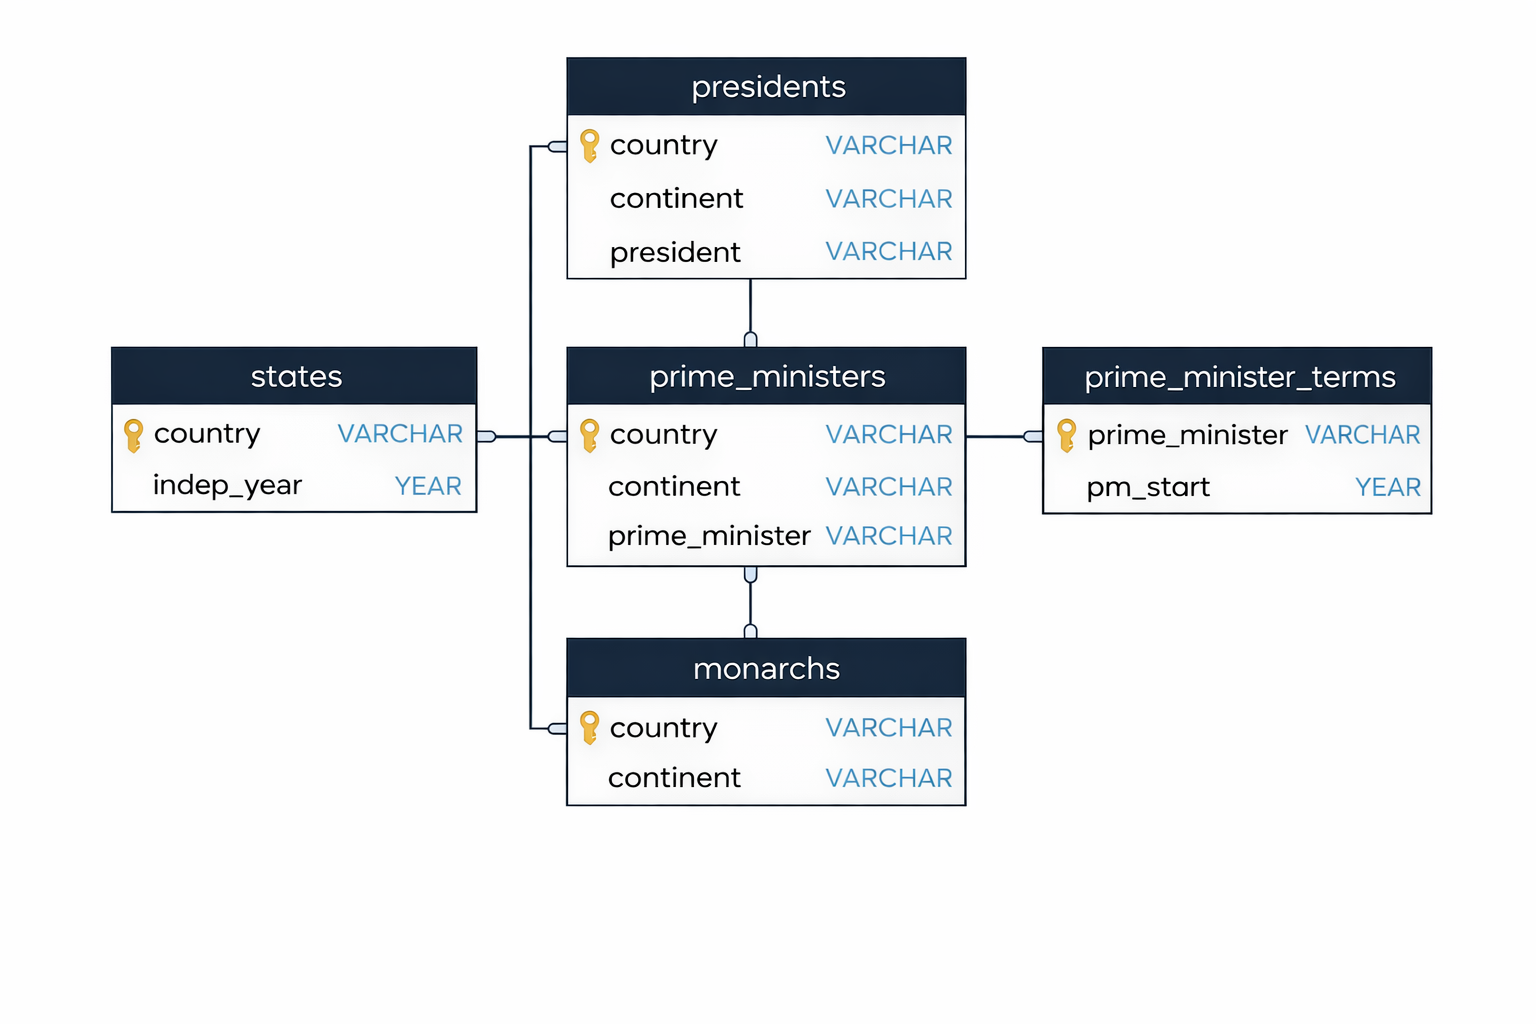

</center>

# UNIONES EN SQL

Ya entendida la estrucutra de la base de datos, Vamos a entrar en materia del entendimiento concreto de SQL; Las uniones SQL permiten combinar datos de tablas diferentes para obtener resultados mas significativos dependiendo de las caracteristicas y necesidades requeridas. Dentro de estas uniones tenermos disponibles:

1. **INNER JOIN:** El objetivo de un INNER JOIN es devolver únicamente los registros que tienen coincidencia en ambas tablas según una condición dada.

2. **LEFT JOIN:** Es un tipo de unión que devuelve todas las filas de la tabla de la izquierda y las filas coincidentes de la tabla de la derecha. Si no hay coincidencia en la tabla de la derecha, el resultado mostrará NULL para las columnas de la tabla de la derecha.




## INNER JOIN

La sintaxis general de una unión interna consiste en indicar primero la tabla base, luego la tabla con la que se va a unir y finalmente la condición de coincidencia:

```sql
SELECT *
FROM tabla_izquierda
INNER JOIN tabla_derecha
ON tabla_izquierda.campo = tabla_derecha.campo;

```

Cuando las dos tablas contienen columnas con el mismo nombre, como country o continent, es necesario especificar el nombre de la tabla junto con la columna para evitar ambigüedad. Por eso se usa la notación tabla.columna.

Por ejemplo:

```sql

SELECT presidents.country, presidents.continent, prime_ministers.prime_minister
FROM presidents
INNER JOIN prime_ministers
ON presidents.country = prime_ministers.country;

```

Como escribir los nombres completos de las tablas varias veces puede ser incómodo, SQL permite asignar alias mediante la palabra clave AS. Esto hace la consulta más compacta y legible:

```sql

SELECT p1.country, p1.continent, p2.prime_minister
FROM presidents AS p1
INNER JOIN prime_ministers AS p2
ON p1.country = p2.country;

```
Además, cuando la columna usada para unir tiene exactamente el mismo nombre en ambas tablas, puede emplearse la cláusula USING, que simplifica la sintaxis:

```sql

SELECT country, continent, prime_minister
FROM presidents
INNER JOIN prime_ministers
USING (country);

```
Entonces el INNER JOIN sirve para encontrar la intersección entre dos tablas con base en un campo común. Es especialmente útil cuando se desea trabajar solo con la información compartida entre ambas estructuras, como ocurre al buscar países que tienen simultáneamente presidente y primer ministro. Entender esta operación es fundamental porque constituye una de las herramientas más importantes del análisis relacional en SQL.

<center>

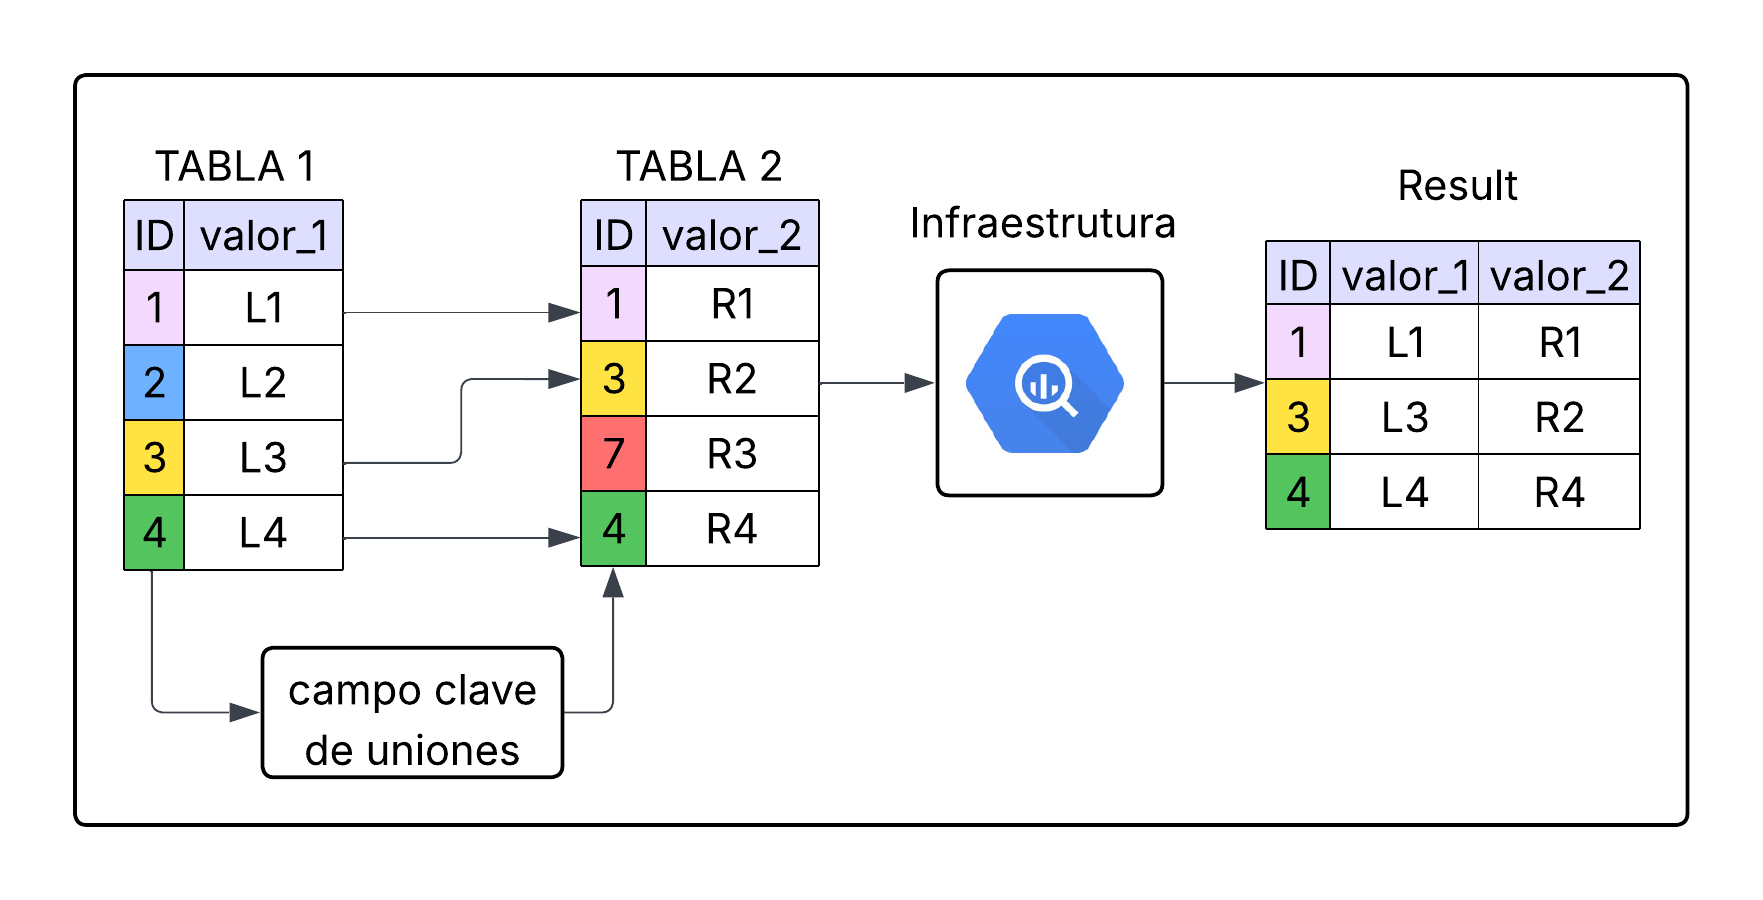

</center>

In [ ]:
#vamos primero a ver algunas tablas de las que tenemos en nuestro data warehouse, estoy usando una conexion directa de google a big query.

%%bigquery --project sql-learn-491702


SELECT *
FROM `sql-learn-491702.country_information_raw.cities`
LIMIT 5


Query is running:   0%|          |

Downloading:   0%|          |

,name,country_code,city_proper_pop,metroarea_pop,urbanarea_pop
0,Abidjan,CIV,4765000,<NA>,4765000
1,Abu Dhabi,ARE,1145000,<NA>,1145000
2,Abuja,NGA,1235880,6000000,1235880
3,Accra,GHA,2070463,4010054,2070463
4,Addis Ababa,ETH,3103673,4567857,3103673


In [ ]:
#miremos la tabla countries

%%bigquery --project sql-learn-491702

SELECT *
FROM `sql-learn-491702.country_information_raw.countries`
LIMIT 5

Query is running:   0%|          |

Downloading:   0%|          |

,code,country_name,continent,region,surface_area,indep_year,local_name,gov_form,capital,cap_long,cap_lat
0,AFG,Afghanistan,Asia,Southern and Central Asia,652090.0,1919,Afganistan/Afqanestan,Islamic Emirate,Kabul,691.761,345.228
1,NLD,Netherlands,Europe,Western Europe,41526.0,1581,Nederland,Constitutional Monarchy,Amsterdam,489.095,523.738
2,ALB,Albania,Europe,Southern Europe,28748.0,1912,Shqiperia,Republic,Tirane,198.172,413.317
3,DZA,Algeria,Africa,Northern Africa,2381740.0,1962,Al-Jazair/Algerie,Republic,Algiers,305.097,367.397
4,ASM,American Samoa,Oceania,Polynesia,199.0,<NA>,Amerika Samoa,US Territory,Pago Pago,-170.691,-142.846


In [ ]:
#haremon una union  interna con la tabla cities a la izquierda y la tabla countries a la derecha no asiganremos alias

%%bigquery --project sql-learn-491702

SELECT *
FROM `sql-learn-491702.country_information_raw.cities`
INNER JOIN `sql-learn-491702.country_information_raw.countries`
ON  `sql-learn-491702.country_information_raw.cities`.country_code = `sql-learn-491702.country_information_raw.countries`.code
LIMIT 5

Query is running:   0%|          |

Downloading:   0%|          |

,name,country_code,city_proper_pop,metroarea_pop,urbanarea_pop,code,country_name,continent,region,surface_area,indep_year,local_name,gov_form,capital,cap_long,cap_lat
0,Kabul,AFG,3414100,<NA>,3414100,AFG,Afghanistan,Asia,Southern and Central Asia,652090.0,1919,Afganistan/Afqanestan,Islamic Emirate,Kabul,691.761,345.228
1,Algiers,DZA,3415811,5000000,3415811,DZA,Algeria,Africa,Northern Africa,2381740.0,1962,Al-Jazair/Algerie,Republic,Algiers,305.097,367.397
2,Oran,DZA,1560329,3454078,1560329,DZA,Algeria,Africa,Northern Africa,2381740.0,1962,Al-Jazair/Algerie,Republic,Algiers,305.097,367.397
3,Luanda,AGO,2825311,<NA>,2825311,AGO,Angola,Africa,Central Africa,1246700.0,1975,Angola,Republic,Luanda,13.242,-881.155
4,Abu Dhabi,ARE,1145000,<NA>,1145000,ARE,United Arab Emirates,Asia,Middle East,83600.0,1971,Al-Imarat al-´Arabiya al-Muttahida,Emirate Federation,Abu Dhabi,543.705,244.764


## Análisis

Se observa que la tabla `cities` contiene originalmente las siguientes columnas:

* `name`
* `country_code`
* `city_proper_pop`
* `metroarea_pop`
* `urbanarea_pop`

Por su parte, la tabla `countries` incluye los campos:

* `code`
* `country_name`
* `continent`
* `region`
* `surface_area`
* `indep_year`
* `local_name`
* `gov_form`
* `capital`
* `cap_long`
* `cap_lat`

En la tabla resultante de la unión se conservan columnas provenientes de ambas tablas. La relación entre ellas se establece mediante los campos `country_code` y `code`, que actúan como claves de correspondencia, aunque tienen nombres distintos. Debido a ello, ambas columnas permanecen en el resultado final, lo que introduce cierta redundancia en la tabla generada, ya que contienen la misma relación lógica entre los registros.


